errorcion

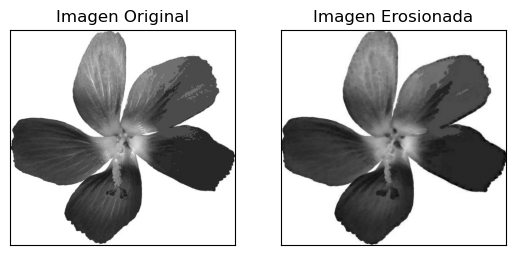

In [16]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
imagen = cv2.imread(r'D:\Franz Caballero\Procesamiento de imagenes\Actividades\Ejercicios python\imagenes\original\flores.jpeg',cv2.IMREAD_GRAYSCALE)

#elemento estructurante
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(5,5))
#aplicar errosión
img_rest=cv2.erode(imagen,kernel)

plt.subplot(121),plt.imshow(imagen,cmap='gray')
plt.title('Imagen Original'), plt.xticks([]), plt.yticks([])
plt.subplot(122),plt.imshow(img_rest,cmap='gray')
plt.title('Imagen Erosionada'), plt.xticks([]), plt.yticks([])
plt.show()





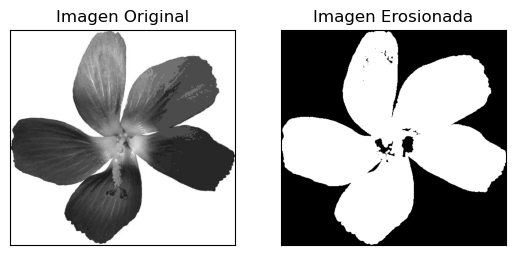

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
imagen = cv2.imread(r'D:\Franz Caballero\Procesamiento de imagenes\Actividades\Ejercicios python\imagenes\original\flores.jpeg',cv2.IMREAD_GRAYSCALE)
_,imgbin=cv2.threshold(imagen,127,255,cv2.THRESH_BINARY_INV)# se puede usar cv2.THRESH_BINARY_INV+cv2.THRESH_OTSU para binarizar la imagen
#elemento estructurante
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(5,5))
#aplicar errosión
img_rest=cv2.dilate(imgbin,kernel,iterations=1)#imgbin es la imagen binarizada o imagen de entrada

plt.subplot(121),plt.imshow(imagen,cmap='gray')
plt.title('Imagen Original'), plt.xticks([]), plt.yticks([])
plt.subplot(122),plt.imshow(img_rest,cmap='gray')
plt.title('Imagen Dilatada'), plt.xticks([]), plt.yticks([])
plt.show()





apertura y cerradura

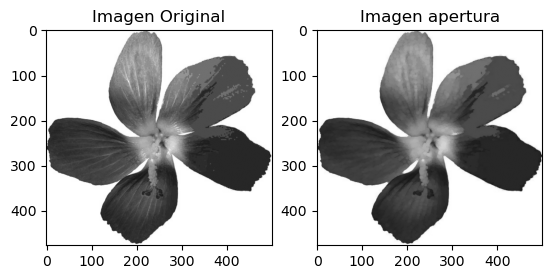

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
imagen = cv2.imread(r'D:\Franz Caballero\Procesamiento de imagenes\Actividades\Ejercicios python\imagenes\original\flores.jpeg',cv2.IMREAD_GRAYSCALE)
#_,imgbin=cv2.threshold(imagen,127,255,cv2.THRESH_BINARY_INV+cv2.THRESH_OTSU)# se puede usar cv2.THRESH_BINARY_INV+cv2.THRESH_OTSU para binarizar la imagen
#elemento estructurante
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(5,5))
#aplicar errosión
#img_rest=cv2.dilate(imgbin,kernel,iterations=1)#imgbin es la imagen binarizada o imagen de entrada
apertura=cv2.morphologyEx(imagen,cv2.MORPH_OPEN,kernel)

plt.subplot(121),plt.imshow(imagen,cmap='gray')
plt.title('Imagen Original'),
plt.subplot(122),
plt.imshow(apertura,cmap='gray')
plt.title('Imagen apertura'), 
plt.show()
#librerias (SKIMAGE=MORPHOLOGY.BINARY_OPEN)




COMO TRABAJAR CON SKIMAGE CON LAS MISMAS TECNICAS DE EROSION , DILATACION y cerradura

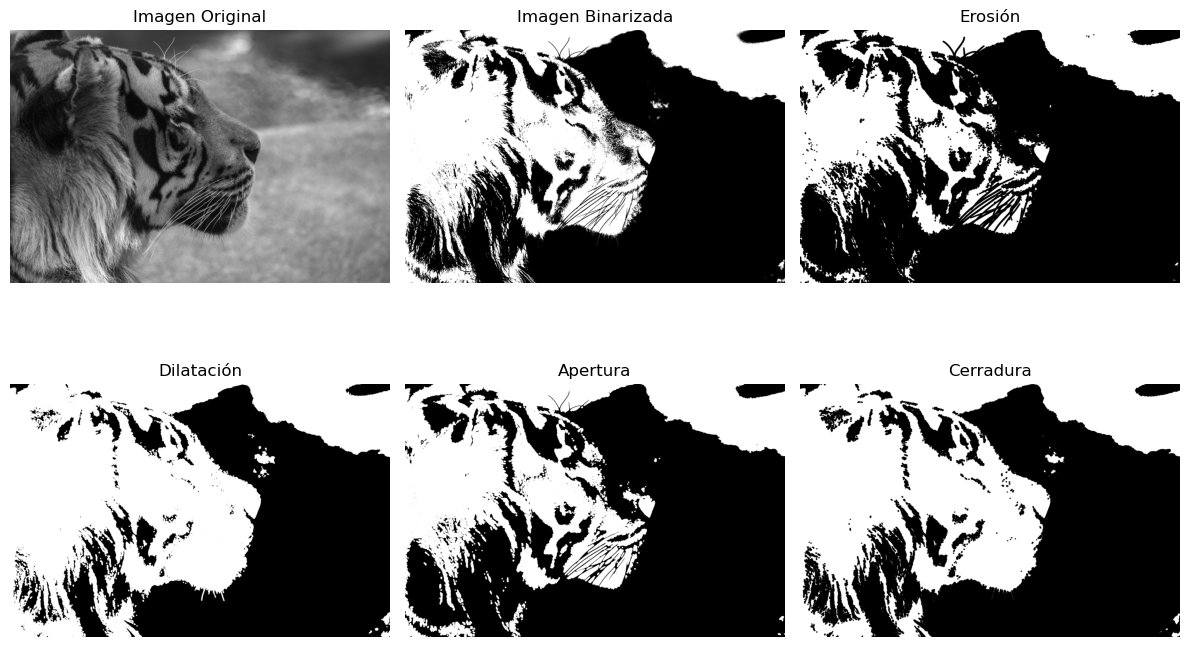

In [54]:

from skimage import morphology
import cv2
import matplotlib.pyplot as plt
import numpy as np
imagen = cv2.imread(r'D:\Franz Caballero\Procesamiento de imagenes\Actividades\Ejercicios python\imagenes\original\tigre.jpeg',cv2.IMREAD_GRAYSCALE)

_, imgbin = cv2.threshold(imagen, 127, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
# elemento estructurante
num = morphology.disk(5)

img_erosion = morphology.binary_erosion(imgbin, num)

img_dilation = morphology.binary_dilation(imgbin, num)

img_opening = morphology.binary_opening(imgbin, num)

img_closing = morphology.binary_closing(imgbin, num)

plt.figure(figsize=(12, 8))
plt.subplot(231), 
plt.imshow(imagen, cmap='gray')
plt.title('Imagen Original'), 
plt.axis('off')
plt.subplot(232), 
plt.imshow(imgbin, cmap='gray')
plt.title('Imagen Binarizada'), 
plt.axis('off')
plt.subplot(233), 
plt.imshow(img_erosion, cmap='gray')
plt.title('Erosión'), 
plt.axis('off')
plt.subplot(234), 
plt.imshow(img_dilation, cmap='gray')
plt.title('Dilatación'), 
plt.axis('off')
plt.subplot(235), 
plt.imshow(img_opening, cmap='gray')
plt.title('Apertura'), 
plt.axis('off')
plt.subplot(236), 
plt.imshow(img_closing, cmap='gray')
plt.title('Cerradura'), 
plt.axis('off')
plt.tight_layout()
plt.show()

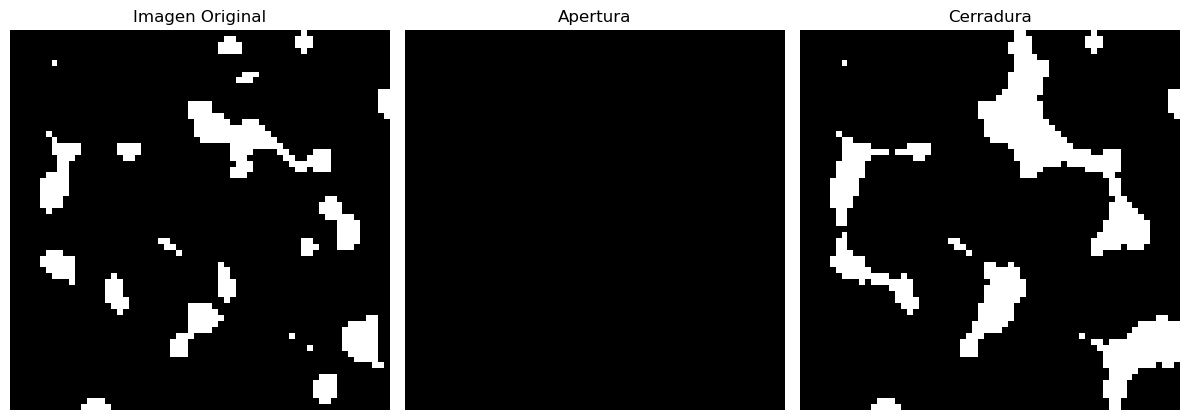

In [33]:

from skimage import data,morphology
import cv2
import matplotlib.pyplot as plt
import numpy as np

image=data.binary_blobs(length=64,n_dim=2,volume_fraction=0.1)
kernel = morphology.disk(5)
apertura = morphology.binary_opening(image, kernel)
cerradura = morphology.binary_closing(image, kernel)
plt.figure(figsize=(12, 8))
plt.subplot(131), plt.imshow(image, cmap='gray')
plt.title('Imagen Original'), plt.axis('off')
plt.subplot(132), plt.imshow(apertura, cmap='gray')
plt.title('Apertura'), plt.axis('off')
plt.subplot(133), plt.imshow(cerradura, cmap='gray')
plt.title('Cerradura'), plt.axis('off')
plt.tight_layout()
plt.show()



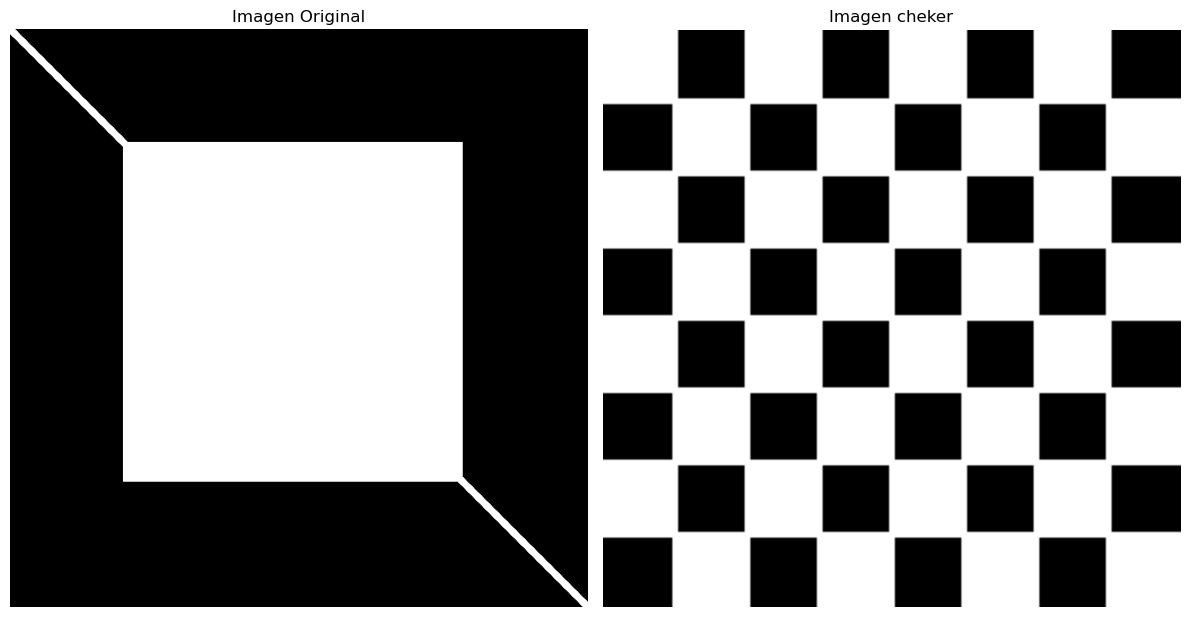

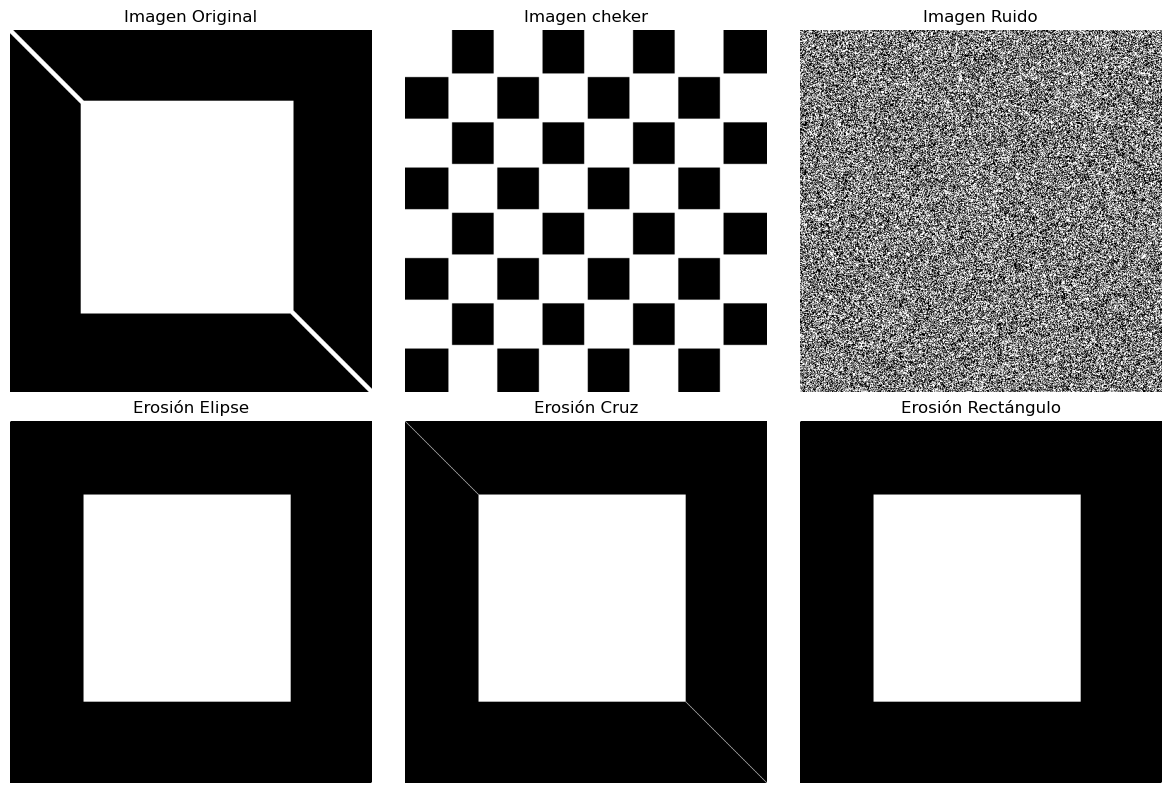

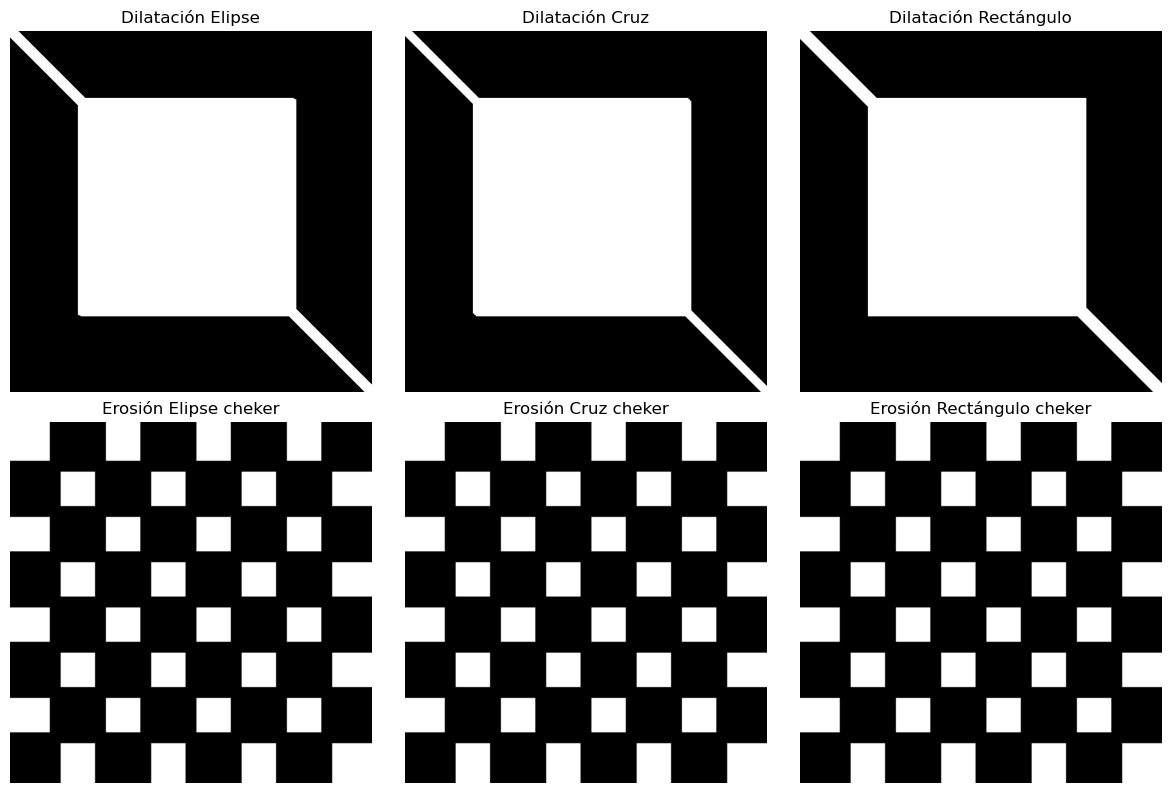

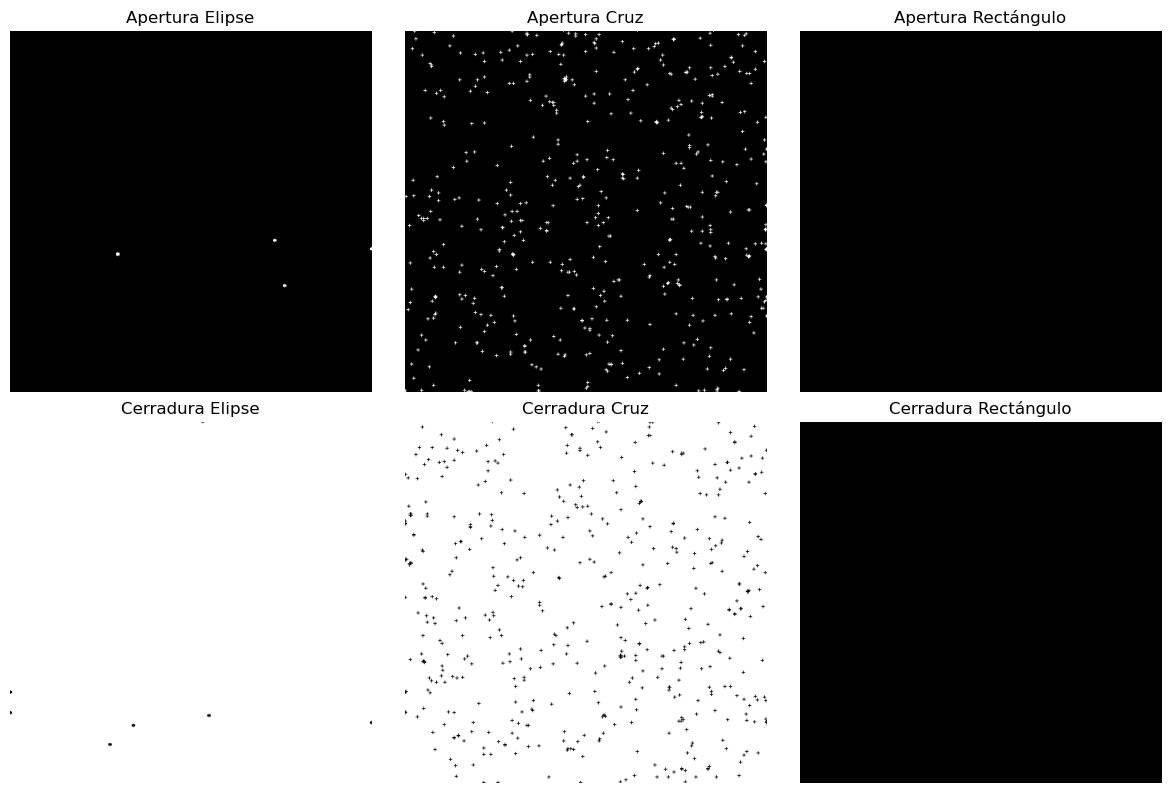

In [68]:
from skimage.data import *
import cv2
import matplotlib.pyplot as plt
import numpy as np
imagen=np.zeros((512,512),np.uint8)

imagen=cv2.circle(imagen,(256,256),100,255,-1)
imagen=cv2.rectangle(imagen,(100,100),(400,400),255,-1)
imagen=cv2.line(imagen,(0,0),(512,512),255,5)

cheker=checkerboard()>0.5
cheker=cheker.astype(np.uint8)*255

plt.figure(figsize=(12, 8))
plt.subplot(121), plt.imshow(imagen, cmap='gray')
plt.title('Imagen Original'), plt.axis('off')
plt.subplot(122), plt.imshow(cheker, cmap='gray')
plt.title('Imagen cheker'), plt.axis('off')
plt.tight_layout()
plt.show()
kernel_ellipse = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
kernel_cross = cv2.getStructuringElement(cv2.MORPH_CROSS, (5, 5))
kernel_rectangle = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
#aplicando erosión
img_erosion_ellipse = cv2.erode(imagen, kernel_ellipse,iterations=2)
img_erosion_cross = cv2.erode(imagen, kernel_cross,iterations=2)
img_erosion_rectangle = cv2.erode(imagen, kernel_rectangle,iterations=2)
#aplicando dilatación
img_dilation_ellipse = cv2.dilate(imagen, kernel_ellipse,iterations=2)
img_dilation_cross = cv2.dilate(imagen, kernel_cross,iterations=2)
img_dilation_rectangle = cv2.dilate(imagen, kernel_rectangle,iterations=2)

cheker_erosion_ellipse = cv2.erode(cheker, kernel_ellipse,iterations=2)
cheker_erosion_cross = cv2.erode(cheker, kernel_cross,iterations=2)
cheker_erosion_rectangle = cv2.erode(cheker, kernel_rectangle,iterations=2)
#aplicando dilatación
cheker_dilation_ellipse = cv2.dilate(cheker, kernel_ellipse,iterations=2)
cheker_dilation_cross = cv2.dilate(cheker, kernel_cross,iterations=2)
cheker_dilation_rectangle = cv2.dilate(cheker, kernel_rectangle,iterations=2)
#crear otra imagen para apertura y cerradura
np.random.seed(45)
imagen_ruido = imagen.copy()
ruido = np.random.randint(0, 2, imagen.shape, dtype=np.uint8) * 255
imagen_ruido = cv2.bitwise_xor(imagen_ruido, ruido)

kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
#aplicando apertura
img_apertura_ellipse = cv2.morphologyEx(imagen_ruido, cv2.MORPH_OPEN, kernel)
img_apertura_cross = cv2.morphologyEx(imagen_ruido, cv2.MORPH_OPEN, kernel_cross)
img_apertura_rectangle = cv2.morphologyEx(imagen_ruido, cv2.MORPH_OPEN, kernel_rectangle)
#aplicando cerradura
img_cerradura_ellipse = cv2.morphologyEx(imagen_ruido, cv2.MORPH_CLOSE, kernel)
img_cerradura_cross = cv2.morphologyEx(imagen_ruido, cv2.MORPH_CLOSE, kernel_cross)
img_cerradura_rectangle = cv2.morphologyEx(imagen_ruido, cv2.MORPH_CLOSE, kernel_rectangle)
plt.figure(figsize=(12, 8))
plt.subplot(231), plt.imshow(imagen, cmap='gray')
plt.title('Imagen Original'), plt.axis('off')
plt.subplot(232), plt.imshow(cheker, cmap='gray')
plt.title('Imagen cheker'), plt.axis('off')
plt.subplot(233), plt.imshow(imagen_ruido, cmap='gray')
plt.title('Imagen Ruido'), plt.axis('off')
plt.subplot(234), plt.imshow(img_erosion_ellipse, cmap='gray')
plt.title('Erosión Elipse'), plt.axis('off')
plt.subplot(235), plt.imshow(img_erosion_cross, cmap='gray')
plt.title('Erosión Cruz'), plt.axis('off')
plt.subplot(236), plt.imshow(img_erosion_rectangle, cmap='gray')
plt.title('Erosión Rectángulo'), plt.axis('off')
plt.tight_layout()
plt.figure(figsize=(12, 8))
plt.subplot(231), plt.imshow(img_dilation_ellipse, cmap='gray')
plt.title('Dilatación Elipse'), plt.axis('off')
plt.subplot(232), plt.imshow(img_dilation_cross, cmap='gray')
plt.title('Dilatación Cruz'), plt.axis('off')
plt.subplot(233), plt.imshow(img_dilation_rectangle, cmap='gray')
plt.title('Dilatación Rectángulo'), plt.axis('off')
plt.subplot(234), plt.imshow(cheker_erosion_ellipse, cmap='gray')
plt.title('Erosión Elipse cheker'), plt.axis('off')
plt.subplot(235), plt.imshow(cheker_erosion_cross, cmap='gray')
plt.title('Erosión Cruz cheker'), plt.axis('off')
plt.subplot(236), plt.imshow(cheker_erosion_rectangle, cmap='gray')
plt.title('Erosión Rectángulo cheker'), plt.axis('off')
plt.tight_layout()
plt.figure(figsize=(12, 8))
plt.subplot(231), plt.imshow(img_apertura_ellipse, cmap='gray')
plt.title('Apertura Elipse'), plt.axis('off')
plt.subplot(232), plt.imshow(img_apertura_cross, cmap='gray')
plt.title('Apertura Cruz'), plt.axis('off')
plt.subplot(233), plt.imshow(img_apertura_rectangle, cmap='gray')
plt.title('Apertura Rectángulo'), plt.axis('off')
plt.subplot(234), plt.imshow(img_cerradura_ellipse, cmap='gray')
plt.title('Cerradura Elipse'), plt.axis('off')
plt.subplot(235), plt.imshow(img_cerradura_cross, cmap='gray')
plt.title('Cerradura Cruz'), plt.axis('off')
plt.subplot(236), plt.imshow(img_cerradura_rectangle, cmap='gray')
plt.title('Cerradura Rectángulo'), plt.axis('off')
plt.tight_layout()
plt.show()

Realiza la conceptualización de los siguientes terminos con su
correspondiente ejemplo en código usando Python y jupyter con librerias
OpenCV y Scikit.image
Transformada Hit_or-Miss
    Algoritmos de morfologia basados en la transformación Hit-or-Miss
Transformaciones geodésicas
Dilatación geodésica
Erocion geodésica

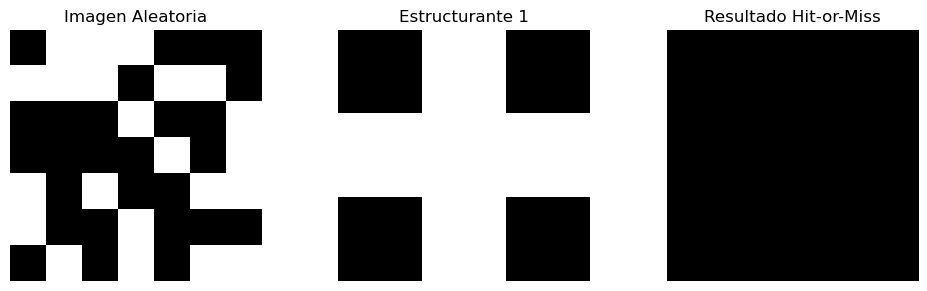

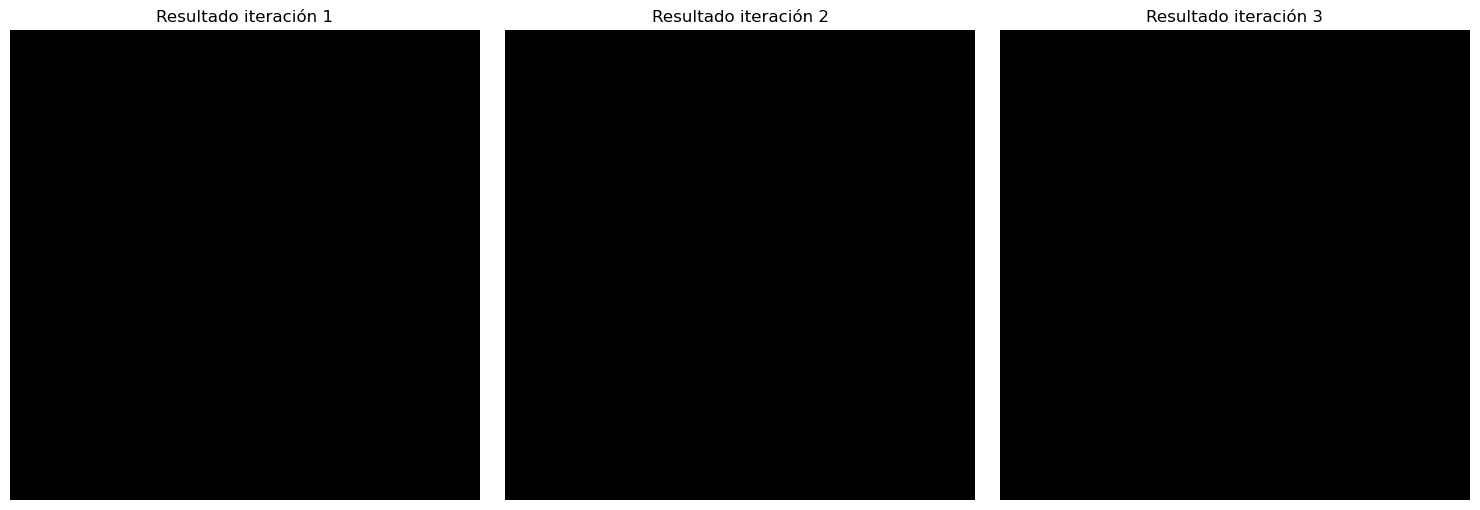

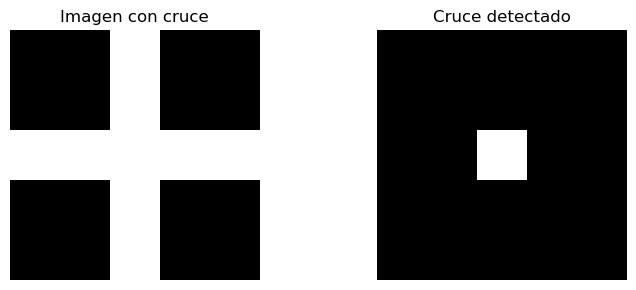

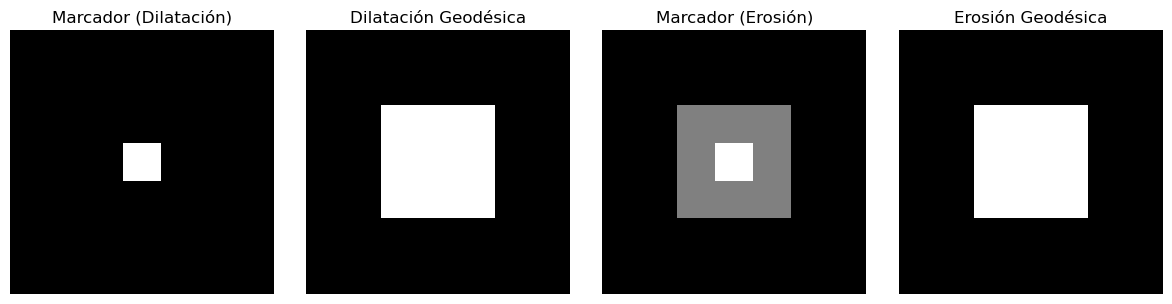

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import binary_hit_or_miss
from skimage.morphology import reconstruction

np.random.seed(42)
image = (np.random.rand(7, 7) > 0.5).astype(np.uint8)

arra1 = np.array([[0, 1, 0],
                  [1, 1, 1],
                  [0, 1, 0]], dtype=bool)

arra2 = np.array([[1, 0, 1],
                  [0, 0, 0],
                  [1, 0, 1]], dtype=bool)

result = binary_hit_or_miss(image, structure1=arra1, structure2=arra2)

plt.figure(figsize=(10, 3))
plt.subplot(131), plt.imshow(image, cmap='gray'), plt.title('Imagen Aleatoria'), plt.axis('off')
plt.subplot(132), plt.imshow(arra1.astype(int), cmap='gray'), plt.title('Estructurante 1'), plt.axis('off')
plt.subplot(133), plt.imshow(result, cmap='gray'), plt.title('Resultado Hit-or-Miss'), plt.axis('off')
plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 5))  # Ajusta el tamaño de la figura

for i in range(3): 
    image = (np.random.rand(7, 7) > 0.5).astype(np.uint8); 
    result = binary_hit_or_miss(image, structure1=arra1, structure2=arra2); 
    plt.subplot(1, 3, i+1)  # Distribuye las imágenes en 1 fila y 3 columnas
    plt.imshow(result, cmap='gray', vmin=0, vmax=1); 
    plt.title(f'Resultado iteración {i+1}'); 
    plt.axis('off') 

plt.tight_layout()  # Ajusta el espaciado entre las subgráficas
plt.show()



image_cross = np.array([[0, 0, 1, 0, 0],
                        [0, 0, 1, 0, 0],
                        [1, 1, 1, 1, 1],
                        [0, 0, 1, 0, 0],
                        [0, 0, 1, 0, 0]], dtype=np.uint8)

struct1 = np.array([[0, 1, 0],
                    [1, 1, 1],
                    [0, 1, 0]], dtype=bool)

struct2 = np.array([[1, 0, 1],
                    [0, 0, 0],
                    [1, 0, 1]], dtype=bool)

result_cross = binary_hit_or_miss(image_cross, structure1=struct1, structure2=struct2)

plt.figure(figsize=(8, 3))
plt.subplot(121), plt.imshow(image_cross, cmap='gray'), plt.title('Imagen con cruce'), plt.axis('off')
plt.subplot(122), plt.imshow(result_cross, cmap='gray'), plt.title('Cruce detectado'), plt.axis('off')
plt.tight_layout()
plt.show()

mask = np.zeros((7, 7), dtype=np.uint8)
mask[2:5, 2:5] = 1
seed = np.zeros_like(mask)
seed[3, 3] = 1

dil_geo = reconstruction(seed, mask, method='dilation')

seed_erosion = mask.copy()
seed_erosion[3, 3] = 2  
ero_geo = reconstruction(seed_erosion, mask, method='erosion')

plt.figure(figsize=(12, 3))
plt.subplot(141), plt.imshow(seed, cmap='gray'), plt.title('Marcador (Dilatación)'), plt.axis('off')
plt.subplot(142), plt.imshow(dil_geo, cmap='gray'), plt.title('Dilatación Geodésica'), plt.axis('off')
plt.subplot(143), plt.imshow(seed_erosion, cmap='gray'), plt.title('Marcador (Erosión)'), plt.axis('off')
plt.subplot(144), plt.imshow(ero_geo, cmap='gray'), plt.title('Erosión Geodésica'), plt.axis('off')
plt.tight_layout()
plt.show()
